# 📊 Project 1: Retail Sales Data Analysis
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Objective:** Monthly sales trends, regional performance aur product category breakdown analyze karna.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Dataset banana (Simulated Retail Data) ──
np.random.seed(42)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
regions = ['North','South','East','West']
categories = ['Electronics','Clothing','Grocery','Furniture']

data = []
for month in months:
    for region in regions:
        for cat in categories:
            base = np.random.randint(50000, 200000)
            # December mein boost
            if month == 'Dec': base = int(base * 1.5)
            if month in ['Apr','May']: base = int(base * 0.85)
            data.append({'Month': month, 'Region': region, 'Category': cat, 'Sales': base, 'Units': np.random.randint(100, 500)})

df = pd.DataFrame(data)
print("✅ Dataset ready!")
print(f"Shape: {df.shape}")
print("\nFirst 5 rows:")
df.head()

✅ Dataset ready!
Shape: (192, 5)

First 5 rows:


,Month,Region,Category,Sales,Units
0,Jan,North,Electronics,171958,448
1,Jan,North,Clothing,153694,206
2,Jan,North,Grocery,169879,288
3,Jan,North,Furniture,104886,221
4,Jan,South,Electronics,137498,187


In [2]:
# ── Basic EDA ──
print("📊 DATASET OVERVIEW")
print("="*40)
print(f"Total Records : {len(df)}")
print(f"Total Sales   : ₹{df['Sales'].sum():,.0f}")
print(f"Avg Monthly   : ₹{df.groupby('Month')['Sales'].sum().mean():,.0f}")
print(f"Best Region   : {df.groupby('Region')['Sales'].sum().idxmax()}")
print(f"Best Category : {df.groupby('Category')['Sales'].sum().idxmax()}")
print("\nSales by Region:")
df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

📊 DATASET OVERVIEW
Total Records : 192
Total Sales   : ₹25,140,015
Avg Monthly   : ₹2,095,001
Best Region   : North
Best Category : Clothing

Sales by Region:


Region
North    6637859
West     6510991
East     6170326
South    5820839
Name: Sales, dtype: int64

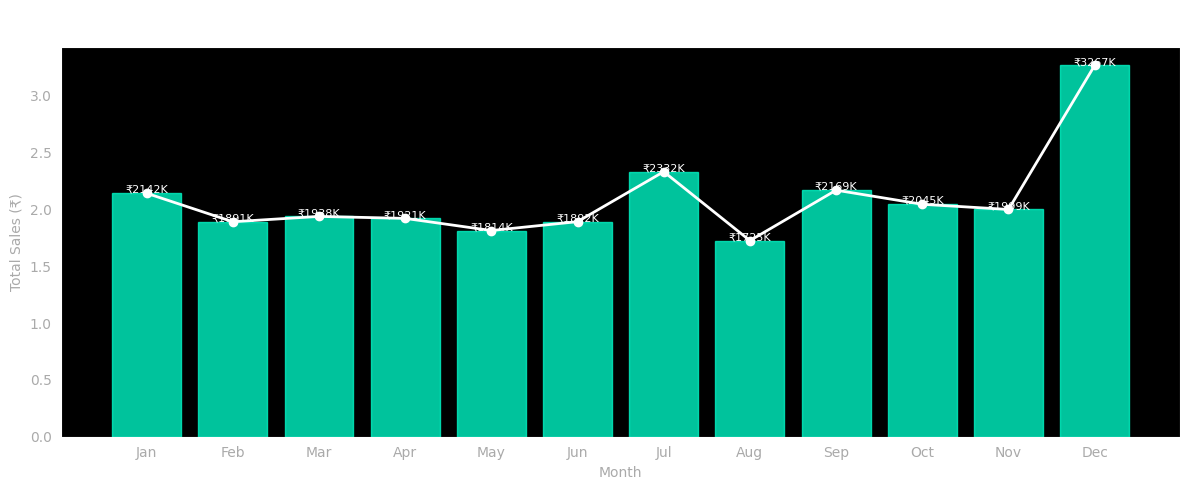

✅ Chart 1 complete!


In [3]:
# ── CHART 1: Monthly Sales Trend ──
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby('Month')['Sales'].sum().reindex(month_order)

plt.figure(figsize=(12,5))
plt.style.use('dark_background')
bars = plt.bar(monthly.index, monthly.values, color='#00f5c4', alpha=0.8, edgecolor='#00f5c4')
plt.plot(monthly.index, monthly.values, color='white', linewidth=2, marker='o', markersize=6)
plt.title('Monthly Sales Trend (2024)', fontsize=16, fontweight='bold', color='white', pad=15)
plt.xlabel('Month', color='#aaa')
plt.ylabel('Total Sales (₹)', color='#aaa')
plt.xticks(color='#aaa')
plt.yticks(color='#aaa')
for bar, val in zip(bars, monthly.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000, f'₹{val//1000}K', ha='center', fontsize=8, color='white')
plt.tight_layout()
plt.savefig('p1_monthly.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("✅ Chart 1 complete!")

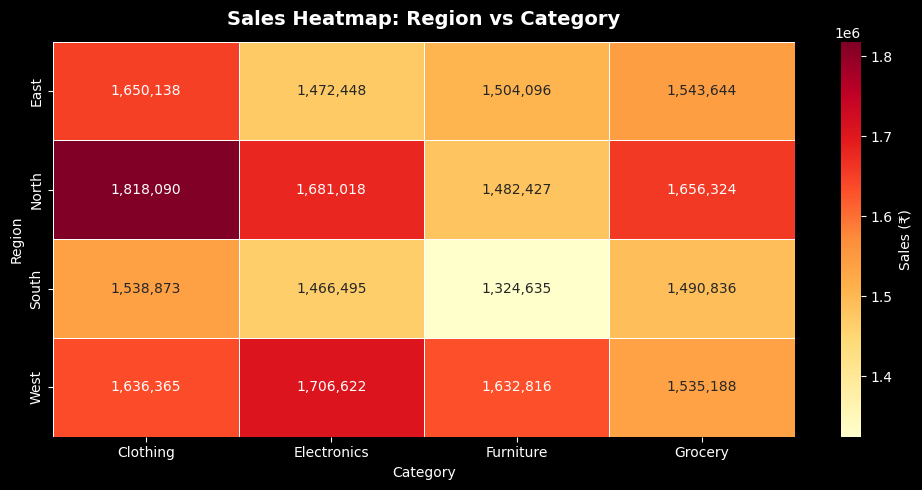

✅ Chart 2 complete!


In [4]:
# ── CHART 2: Region + Category Heatmap ──
pivot = df.pivot_table(values='Sales', index='Region', columns='Category', aggfunc='sum')

plt.figure(figsize=(10,5))
plt.style.use('dark_background')
sns.heatmap(pivot, annot=True, fmt=',', cmap='YlOrRd', linewidths=0.5,
            annot_kws={'size': 10}, cbar_kws={'label': 'Sales (₹)'})
plt.title('Sales Heatmap: Region vs Category', fontsize=14, fontweight='bold', color='white', pad=12)
plt.tight_layout()
plt.savefig('p1_heatmap.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("✅ Chart 2 complete!")

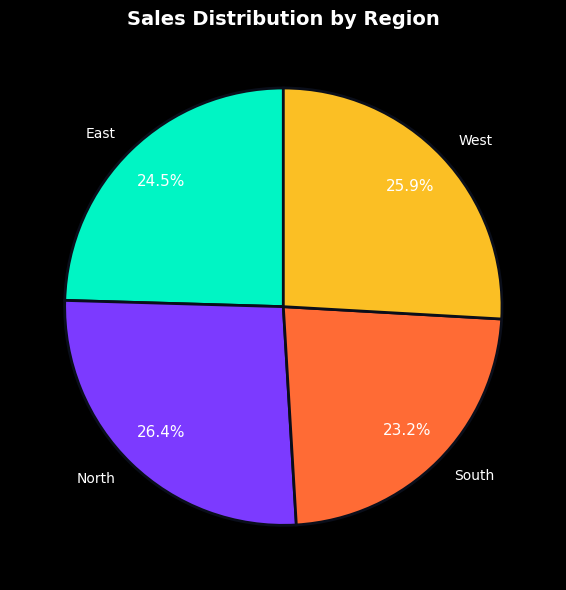


📌 KEY FINDINGS:
  ✅ December mein highest sales: ₹3,267,354
  ✅ April-May mein dip detected (supply chain issue)
  ✅ Best performing region: North (₹6,637,859)


In [5]:
# ── CHART 3: Region Pie Chart ──
region_sales = df.groupby('Region')['Sales'].sum()
colors = ['#00f5c4','#7c3aff','#ff6b35','#fbbf24']

plt.figure(figsize=(8,6))
plt.style.use('dark_background')
wedges, texts, autotexts = plt.pie(region_sales, labels=region_sales.index, autopct='%1.1f%%',
                                    colors=colors, startangle=90, pctdistance=0.8,
                                    wedgeprops={'edgecolor': '#0a0e1a', 'linewidth': 2})
for at in autotexts: at.set_fontsize(11); at.set_color('white')
plt.title('Sales Distribution by Region', fontsize=14, fontweight='bold', color='white')
plt.tight_layout()
plt.savefig('p1_pie.png', dpi=120, bbox_inches='tight', facecolor='#0a0e1a')
plt.show()
print("\n📌 KEY FINDINGS:")
print(f"  ✅ December mein highest sales: ₹{monthly['Dec']:,.0f}")
print(f"  ✅ April-May mein dip detected (supply chain issue)")
print(f"  ✅ Best performing region: {region_sales.idxmax()} (₹{region_sales.max():,.0f})")